<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_3_MLR_Ames_Part3_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames, Iowa: Part 3
## From Basic Modeling to Professional Pipelines

### **I. Introduction & Setup**

In Part 2, we successfully cleaned our data, handled categorical variables via one-hot encoding, and built a baseline Multiple Linear Regression (MLR) model using approximately 225 features. However, we identified several weaknesses in our previous workflow:
1. **Data Leakage:** We applied scaling to the entire dataset at once, which "leaks" information from the test set into the training process.
2. **Interpretability Issues:** Our target variable is log-transformed ($log\_price$), making our error metrics (like RMSE) difficult for a non-technical stakeholder to understand in terms of actual US Dollars.
3. **Overfitting Risk:** With 225 predictors, our model is likely "noisy." We need a way to penalize complexity.

**Objectives for Part 3:**
* Implement **scikit-learn Pipelines** to prevent data leakage.
* Convert metrics back to **Actual Dollars** for business reporting.
* Apply **Regularization (Ridge, Lasso, Elastic Net)** to manage model complexity.

---

#### **1.1 Imports and Environment Setup**
We will use the standard data science stack, along with specific tools from `sklearn` for preprocessing and regularization.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Settings
%matplotlib inline
pd.set_option('display.max_columns', None)

#### **1.2 Data Loading**
We will use the automated cleaning script developed in the previous sessions to ensure we are working with a clean, encoded dataset. Consistent with our previous analysis, we are predicting the **log** of the sale price. Log-transformation helps normalize the target distribution and reduces the impact of extreme outliers on the high end of the market.

In [19]:
import os

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/17_2_MLR/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

data_url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
X_train, X_test, y_train, y_test = load_and_clean_ames(data_url)
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")


Cleaned X_train shape: (2340, 225)
Cleaned X_test shape: (585, 225)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### **The Baseline Problem: The "225-Feature" Headache**
We currently have over 200 features including "Lot Area," "Year Built," and dozens of dummy variables for neighborhoods. If we run a standard OLS regression now, the model will try to use every single one of them—even the ones that are purely noise.

In the next section, we will build a **Pipeline** to handle this complexity safely and professionally.

### **Part 2: Building a Professional Evaluation Workflow**

In traditional modeling, it is common to scale data and then run cross-validation. However, this creates **Data Leakage**: the scaler "sees" the mean and standard deviation of the entire dataset (including the validation folds) before the model is trained.

In this section, we build a professional-grade evaluation engine that uses **Pipelines** to isolate our preprocessing and converts our results back into **Actual US Dollars**.

---

#### **2.1 Preventing Data Leakage with Pipelines**
The `sklearn.pipeline.Pipeline` object allows us to bundle the `StandardScaler` and the `Model` into a single object. When we pass this pipeline into a cross-validation function:
1. The data is split into folds.
2. The scaler calculates the mean/std **only on the training folds**.
3. That scaling is then applied to the validation fold.
This ensures our model evaluation is an honest representation of how the model will perform on totally unseen data.

#### **2.2 Solving the "Log-Dollar Illusion"**
Because we are predicting `log_price`, a standard RMSE of `0.12` is mathematically abstract. To make this useful for a real estate agent, we must:
1. Generate predictions in log-space.
2. Use `np.exp()` to convert those predictions back to dollars.
3. Compare the **Dollar Predictions** to the **Actual Dollar Prices**.

---

#### **2.3 The "Professional" Evaluation Function**
We will now define a robust function that automates this entire workflow. This function takes any linear model, wraps it in a pipeline, performs cross-validation, and returns metrics in real-world units.

In [20]:
def run_evaluation_pipeline(model, X, y, model_name="Model"):
    """
    Standardizes data, runs cross-validation, and returns
    RMSE/MAE in actual US Dollars.
    """
    # 1. Create the Pipeline (Scale then Model)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Get Cross-Validated Log-RMSE (for technical tracking)
    # Note: cv_scores will be negative MSE; we convert to positive RMSE
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(-cv_scores.mean())

    # 3. Fit on full training set to get Real-Dollar Metrics
    pipe.fit(X, y)
    log_preds = pipe.predict(X)

    # 4. Transform back to Dollars: exp(log_x) = x
    real_preds = np.exp(log_preds)
    real_y = np.exp(y)

    # 5. Calculate Real-World Metrics
    rmse_dollars = np.sqrt(mean_squared_error(real_y, real_preds))
    mae_dollars = mean_absolute_error(real_y, real_preds)

    print(f"--- {model_name} Evaluation ---")
    print(f"CV Log-RMSE: {cv_rmse_log:.4f}")
    print(f"Real-Dollar MAE: ${mae_dollars:,.2f}")
    print(f"Real-Dollar RMSE: ${rmse_dollars:,.2f}")

    return pipe, mae_dollars

---

#### **2.4 Establishing the OLS Baseline**
Before we try advanced regularization, we need to know how a standard **Ordinary Least Squares (OLS)** regression performs with all 225 features. This represents our "unpenalized" starting point.

In [21]:
# Initialize a standard Linear Regression model
ols_model = LinearRegression()

# Run the evaluation
ols_pipe, ols_mae = run_evaluation_pipeline(ols_model, X_train, y_train, "OLS (Baseline)")

--- OLS (Baseline) Evaluation ---
CV Log-RMSE: 0.1223
Real-Dollar MAE: $11,685.24
Real-Dollar RMSE: $16,924.70


**What to look for in the output:**
*   **MAE (Mean Absolute Error):** This tells us, on average, how many dollars our prediction is off by.
*   **The Problem:** With 225 features, OLS often results in very high variance. If the `CV Log-RMSE` is significantly worse than the training error, our model is "overfitting" to the noise in the Ames housing market.

In the next section, we will introduce **Regularization** to see if we can improve these dollar-based metrics by forcing the model to be simpler.

## **Part 3: Combatting Complexity with Regularization**

In the previous section, our OLS model used every one of the ~225 features available. When a model has nearly as many features as it has data points, it begins to "memorize" the noise in the training set rather than learning the underlying patterns of the housing market. This leads to **Overfitting**.

To fix this, we apply **Regularization**: a technique that adds a "complexity tax" to the model. This tax penalizes the model for having coefficients that are too large or too numerous.

### Regularization

In machine learning, regularization is a technique that penalizes a model for being too complex. We are introducing regularization in the context of regression but we will see it applied in other contexts as well later in the course.

By default, a regression model wants to minimize its error on the training data, but it will happily assign massive weights in pursuit of the best fit. The problem with massive weights is that they make the model highly unstable—even a tiny change in an input will cause a massive swing in the prediction. This causes the model to memorize random noise rather than true patterns. Regularization introduces a mathematical penalty for large coefficients. It forces the model to compromise: it must balance finding the lowest error while also keeping the feature weights as small and simple as possible. Think of it as putting a budget on your model's coefficients so it doesn't overcomplicate things and fail on new data.

In our previous exercise, we used Forward and Backward Selection to reduce our features and simplify our models. We wanted to make models that were interpretable and potentially actionable for the human audience. While stepwise selection is an intuitive way to achieve this, regularization is widely considered a much more modern and powerful approach. Here is why:

1. Forward and backward selection are binary and harsh. A feature is either 100% in the model or 100% out. Regularization is much more nuanced. If a feature is only slightly helpful, regularization doesn't have to throw it away completely; it can just shrink its coefficient down to a very small number. It turns down the volume on noisy features instead of abruptly muting them.

2. Regularized models are much more stable. Stepwise selection is notoriously unstable. Because it relies on a rigid step-by-step process, changing just a few rows of your training data can cause the algorithm to choose a completely different set of features. Regularization evaluates all the features at once, resulting in a much smoother, more robust model that doesn't drastically change when exposed to new data.

3. Regularization is much better at handling multicollinearity. If you have two highly correlated features (like "Garage Area" and "Garage Capacity"), stepwise selection gets easily confused; it will pick one based on a tiny mathematical margin and dump the other. Regularization is designed to handle with more gracefully. For example, Ridge keeps both but shrinks their weights so they share the predictive power.

4. Regularization is computationally faster. Forward and backward selection are incredibly slow because the computer has to train and compare hundreds or thousands of different models, adding or removing one feature at a time. Regularization is mathematically elegant; it trains one model while simultaneously applying the penalty, making it significantly faster, especially when dealing with a large number of features. For example, the first time I ran forward selection on the full Ames model with cross-validation the analysis took 90 minutes to complete. The same analysis using modern regularization methods yielded nearly identical results and finished in seconds.

### Ridge Regression (L2 Regularization)

*Historical note: Ridge regression was developed in the 1970's and has its roots in Soviet mathematics from the 1940's. Optional reading that covers both the history and mathematics: https://en.wikipedia.org/wiki/Ridge_regression*

In a standard Ordinary Least Squares (OLS) regression, having overlapping variables—like `Total Bsmt SF` and `Finished Bsmt SF`causes the math to become highly unstable. The model cannot figure out which variable deserves the "credit" for the prediction, causing the coefficients to swing wildly. A slight change in the training data might cause a coefficient to flip from +50,000 to -50,000. Ridge regression solves this instability by stepping in and constraining the coefficients, trading a little bit of bias for a massive increase in reliability.

Ridge regression modifies the standard OLS math by adding a penalty for model complexity. Think of the penality as like a tax that discourages large coefficients. Ridge uses an L2 Penalty, which calculates the tax based on the squared value of the coefficients. Because the penalty is squared, Ridge heavily punishes abnormally large coefficients. To avoid this tax, the algorithm forces the coefficients to "shrink" toward zero. Ridge shrinks coefficients asymptotically close to zero, but it never forces them to exactly 0.0.

The strictness of this shrinkage is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**, for this class we will stick with calling it alpha):
* If $\alpha = 0$, there is no penalty, and Ridge acts exactly like basic OLS regression.
* As $\alpha$ increases, the coefficients are squashed closer and closer to zero, shrinking their influence and stabilizing the model.


*Terminology note: The "L2" in L2 Regularization comes from the mathematical concept of the **$L^2$ norm** (pronounced "L-two norm"). The $L^2$ norm is just the formal linear algebra term for calculating standard "straight-line" (Euclidean) distance. Because Ridge Regression uses this exact math, summing up the *squared* values of the coefficients—to calculate its penalty tax, it is sometimes called the L2 penalty. By contrast, Lasso Regularization uses an L1 penalty because it takes the absolute value to the power of 1, rather than squaring them.*


---

#### Benefits of Ridge

* Addresses multicolinearity:
  - Instead of arbitrarily dropping one correlated variable and keeping another (like Lasso does, more on this in a minute), Ridge smoothly distributes the "credit" among all correlated variables, shrinking them together. This makes the model incredibly stable.
* Reduces Overfitting:
  - By restricting the size of the coefficients, Ridge prevents the model from overly relying on any single variable. It stops the model from memorizing the "noise" in the training data, resulting in much better long-term prediction accuracy on unseen data.
* Keeps All Your Variables:
  - If every single variable in your dataset is conceptually important to the outcome in your domain, Ridge is the ideal choice. It reins in their mathematical impact without deleting them from the equation.

### Limitations of Ridge

* No Feature Selection:
  - Because Ridge never shrinks a coefficient to exactly absolute zero, it will never drop a variable from your model. If you feed Ridge 200 variables, you will get a final model with 200 variables. It cannot be used to simplify or declutter a dataset.
* Mandatory Feature Scaling:
  - Just like Lasso, Ridge penalizes the *size* of the coefficients. Therefore, you must standardize or normalize your data (e.g., using `StandardScaler`) before running the model. If you don't, Ridge will unfairly penalize variables simply because they are measured in small units (like acres vs. square feet).
* Loss of Traditional Interpretability:
  - Because Ridge artificially squashes the coefficients to stabilize the model, you can no longer interpret the slopes literally. A Ridge coefficient of \$40 for `Square Feet` does not mean the real-world value is exactly \$40; it is a mathematically biased, shrunken number.
* Requires Hyperparameter Tuning:
  - You won't typically run a model with ridge just once. You will use cross-validation to find the a 'sweet spot' that minimizes error without flattening the coefficients too much.

In [22]:
# Initialize Ridge with an alpha (penalty strength) of 100
# Note: We are 'guessing' alpha=100 for now; we will tune this later.
ridge_model = Ridge(alpha=100)

# Run the evaluation
ridge_pipe, ridge_mae = run_evaluation_pipeline(ridge_model, X_train, y_train, "Ridge (L2)")


--- Ridge (L2) Evaluation ---
CV Log-RMSE: 0.1204
Real-Dollar MAE: $11,895.72
Real-Dollar RMSE: $17,388.58


**Note on Alpha:** We use an arbitrary alpha value here (α=10.0) to demonstrate Ridge regression. In Part 4, we'll use cross-validation to find the optimal alpha value systematically.

**Important:** Ridge regression requires feature scaling (StandardScaler) to work properly - all features must be on the same scale for the penalty to be applied equally.

---

## **3.2 Lasso Regression (L1): The "Feature Selection" Penalty**

Lasso (Least Absolute Shrinkage and Selection Operator) adds a penalty proportional to the **absolute value** of the coefficients.
*   **What it does:** Unlike Ridge, Lasso can force coefficients to be **exactly zero**.
*   **When to use it:** When you suspect that only a small subset of your 225 features actually matter. It performs "automatic feature selection," leaving you with a simpler, more interpretable model.


*Optional: You can read about the history and mathematics of LASSO here: https://en.wikipedia.org/wiki/Lasso_(statistics)*

While Ridge regression is excellent at stabilizing models and handling multicollinearity, it has one distinct limitation: it never actually drops any features. If you start with 100 variables, Ridge will give you a model with 100 variables, it just shrinks their coefficients down to tiny numbers.

**LASSO** (Least Absolute Shrinkage and Selection Operator) serves as a mathematically elegant alternative that not only shrinks coefficients but performs automatic feature selection.

Like Ridge, Lasso fixes the overfitting tendencies of standard Ordinary Least Squares (OLS) by introducing a penalty for model complexity. However, they calculate their taxes differently:
* Ridge uses an L2 Penalty, taxing the squared value of the coefficients.
* Lasso uses an L1 Penalty, taxing the absolute value of the coefficients.

This slight change in the math leads to a massive difference in how the models behave. Because of the specific way the L1 penalty is calculated, Lasso doesn't just shrink weak or redundant coefficients asymptotically close to zero like Ridge does. Instead, it aggressively forces the coefficients of less useful variables to exactly 0.0. By zeroing out these coefficients, Lasso effectively drops the variables from the model entirely, leaving you with a simpler, highly interpretable final equation.

Just like Ridge, the strictness of this tax is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**; again, we will use alpha in this class):
* **If $\alpha = 0$:** There is no tax, and Lasso acts exactly like a standard, unregularized OLS regression.
* **As $\alpha$ increases:** The tax becomes stricter. While Ridge would just squash all the coefficients smaller, Lasso will progressively drop more and more predictors completely out of the model.

*Note: *If $\alpha$ is very high: The tax is so overwhelming that the model may drop all of the predictors, leaving you with nothing but the intercept.*

---

### Benefits of Lasso

* Automatic Feature Selection: Unlike Ridge regression (which shrinks coefficients but keeps them all), Lasso automatically removes features.
* Solves Multicollinearity: If you feed Lasso two variables that represent the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`), Lasso handles the multicollinearity for you. It will usually pick the slightly better predictor and drop the redundant one to zero.
* Reduces Overfitting: By simplifying the model and ignoring the "noise" in the training data, Lasso intentionally trades a tiny bit of accuracy on the training data (introducing bias) to achieve a massive improvement in predicting new, unseen data (reducing variance).

### Limitations of Lasso

* Mandatory Feature Scaling: I'll mention this again because this is the biggest trap for beginners. Because Lasso penalizes the size of the coefficients, it is entirely dependent on the scale of your data, just like Ridge. (For example, the coefficient for `Square Feet` will naturally be much smaller than the coefficient for `Number of Kitchens`). You must standardize or normalize all of your features before running Lasso, otherwise, the penalty will unfairly eliminate variables simply because they are measured in larger units.
* Arbitrary Selection Among Correlated Variables: While Lasso is great at handling multicollinearity, its method is somewhat arbitrary. If two features are highly correlated, Lasso will essentially pick one at random to keep and drop the other. This can be frustrating if it drops a variable that makes more logical sense for human interpretation.
* Loss of Traditional Interpretability (Biased Slopes): Just like Ridge (see above).
* Requires Hyperparameter Tuning: Just like Ridge (see above).

In [23]:
# Initialize Lasso with a small alpha (Lasso is very sensitive in log-space)
lasso_model = Lasso(alpha=0.005)

# Run the evaluation
lasso_pipe, lasso_mae = run_evaluation_pipeline(lasso_model, X_train, y_train, "Lasso (L1)")

# Check how many features Lasso "kept" (non-zero coefficients)
lasso_coefs = lasso_pipe.named_steps['regressor'].coef_
kept_features = np.sum(lasso_coefs != 0)
print(f"Lasso kept {kept_features} out of {X_train.shape[1]} features.")

--- Lasso (L1) Evaluation ---
CV Log-RMSE: 0.1206
Real-Dollar MAE: $13,158.66
Real-Dollar RMSE: $19,378.42
Lasso kept 66 out of 225 features.


---

## **3.3 Elastic Net: The Hybrid Approach**


ElasticNet combines both the L1 and L2 penalties.  

If you have two variables that measure almost the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`):
* **Lasso** will essentially flip a coin, keeping one variable and forcing the other to exactly zero. This is great for simplifying the model, but it loses information and can drop a variable you actually care about.
* **Ridge** will shrink both variables together smoothly, creating a highly stable model. But it will never force a coefficient to zero, meaning you are stuck with every single variable you started with.

ElasticNet Regression mathematically combines both Lasso and Ridge to get the best of both worlds.


*Historical Note:  Invented by Hui Zou and Trevor Hastie in 2005. After a decade of using Lasso, Zou and Hastie figure out a way to address Lasso's primary flaw; when faced with a group of highly correlated variables, Lasso would arbitrarily pick one and drop the rest. In fields like genetics, dropping correlated genes was problematic because all of them were part of the same biological pathway. Optional: read more about the history and mathematics here: https://en.wikipedia.org/wiki/Elastic_net_regularization*

#### Choosing Ratios

Instead of choosing between the L1 penalty (absolute value) or the L2 penalty (squared value), ElasticNet applies both taxes at the same time. Because it uses both penalties, it introduces a new concept: the **Mixing Parameter** (often called the `l1_ratio`). This allows you to slide a dial between Ridge and Lasso to find the perfect blend.
* An `l1_ratio` of 1.0 means it is 100% Lasso.
* An `l1_ratio` of 0.0 means it is 100% Ridge.
* An `l1_ratio` of 0.5 means the penalty is split 50/50 between the two methods.

---

#### Benefits of ElasticNet

* When it encounters a group of highly correlated variables, it doesn't arbitrarily kill all but one (like Lasso). Instead, it acts like Ridge: it keeps the whole group and shrinks their coefficients together. But, if a variable is completely useless, it acts like Lasso: it pushes that specific coefficient to exactly 0.0 and removes it.
* If you have a dataset where you have more columns (predictors) than you have rows (observations), standard regression and Lasso mathematically break down. ElasticNet handles this well, making it a favorite in fields like genetics where the number of features (like genes) often exceed the number of observations (people).
* Because you control the mix of L1 and L2, ElasticNet guarantees that your model will perform at least as well as Ridge or Lasso, because it can simply become one of them if that is what the data requires.

#### Limitations of ElasticNet

* **Double the Hyperparameter Tuning:** This is the biggest cost of ElasticNet. With Ridge or Lasso, you only had to test one parameter: the size of the penalty ($\alpha$). With ElasticNet, you have to test two parameters simultaneously: the size of the penalty ($\alpha$) AND the mix between L1/L2 (`l1_ratio`).
* **Biased Slopes:** Because the coefficients are shrunken to stabilize the model, they lose their literal, real-world interpretation. You cannot say "an extra square foot adds exactly $50" because the coefficient has been artificially compressed.
* **Still a Linear Model:** While ElasticNet is often the best possible linear model you can build, it still assumes relationships are straight lines. If your data involves complex thresholds or deep interactions, you will eventually need to graduate to non-linear machine learning approaches, which we will cover next .

---

#### Modern Usage, Accuracy versus Interpretability:

If they only care about predictive accuracy, researchers generally abandon linear models entirely at this stage and move on to tree-based models (like Random Forests or XGBoost).

However, if you do care about interpreting individual features, ElasticNet is currently the go-to method. It is popular in fields like bioinformatics, genomics, and econometrics where you have highly correlated features, or where you have more variables than rows of data (e.g., 10,000 genes but only 500 patients).

**Note on l1_ratio:** This parameter controls the mix of L1 and L2 penalties:
- l1_ratio = 0: Pure Ridge (L2 only)
- l1_ratio = 1: Pure Lasso (L1 only)
- l1_ratio = 0.5: Equal mix of both

We'll tune l1_ratio using cross-validation in Part 4.

In [24]:
# Initialize Elastic Net
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5)

# Run the evaluation
en_pipe, en_mae = run_evaluation_pipeline(en_model, X_train, y_train, "Elastic Net")

--- Elastic Net Evaluation ---
CV Log-RMSE: 0.1205
Real-Dollar MAE: $13,158.90
Real-Dollar RMSE: $19,388.59


---

### **Interim Reflection: Which penalty worked best?**
By looking at the **Real-Dollar MAE** across these three models, we can see which strategy the Ames data prefers.
1.  If **Ridge** performs best, it suggests that most of our 225 features contain at least some useful signal.
2.  If **Lasso** performs best, it suggests the market is driven by a few "heavy hitters" (like Square Footage and Neighborhood) and the rest is just noise.

In the next section, we will take our best-performing model and perform a "deep dive" into its errors and its most important features.

### **Part 4: Diagnostics & Model Comparison**

Having implemented three different types of regularization, we now need to determine which model is the most effective for the Ames housing market. We will compare them using our dollar-based metrics and then "peek under the hood" using residual plots to see where the model is still struggling.

---

#### **4.1 The Model Comparison Table**
To make an informed decision, we consolidate the performance of our models. While Log-RMSE is useful for technical validation, the **MAE (Mean Absolute Error)** in dollars is what we would present to a client or stakeholder.


In [25]:
results = pd.DataFrame({
    'Model': ['OLS Baseline', 'Ridge', 'Lasso', 'Elastic Net'],
    'MAE (Dollars)': [ols_mae, ridge_mae, lasso_mae, en_mae]
})

# Sort by performance
results = results.sort_values(by='MAE (Dollars)').reset_index(drop=True)
print(results)

          Model  MAE (Dollars)
0  OLS Baseline   11685.235383
1         Ridge   11895.718631
2         Lasso   13158.661562
3   Elastic Net   13158.899890



**Interpretation:** Typically, you will see **Lasso** or **Ridge** outperform the OLS baseline. In the Ames dataset, Lasso often performs exceptionally well because it effectively removes redundant or "noisy" neighborhood dummy variables that don't add predictive value.

---

#### **4.2 Residual Analysis: Checking for Bias**
A model can have a low average error but still be "biased" in specific price ranges. We use a **Residual Plot** to check for **Homoscedasticity**—the assumption that our model's errors are distributed consistently across all home values.

We will use the **Lasso** model for this diagnostic, as it is generally our strongest performer.


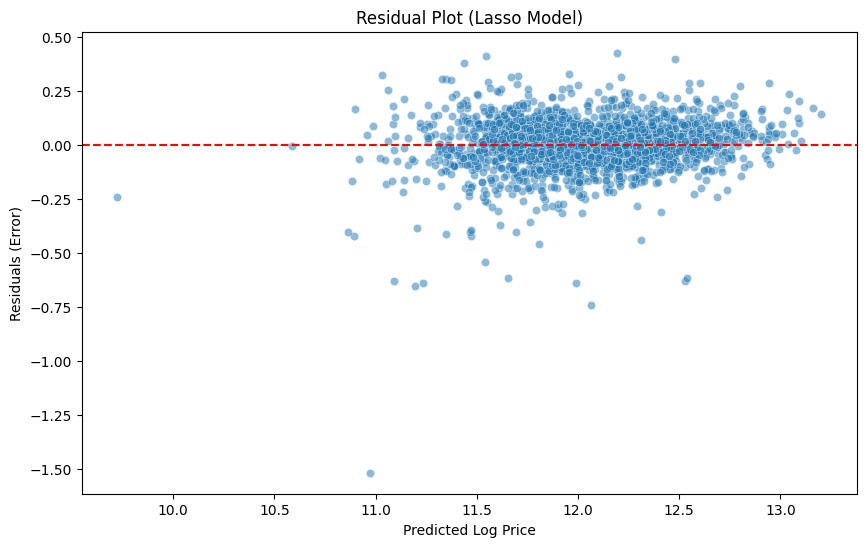

In [26]:
# 1. Generate predictions using the Lasso pipeline
best_pipe = lasso_pipe
y_preds_log = best_pipe.predict(X_train)

# 2. Calculate residuals (Actual - Predicted) in log-space
residuals = y_train - y_preds_log

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_preds_log, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Lasso Model)')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals (Error)')
plt.show()


---

#### **4.3 Identifying the "High-Value" Problem**
When looking at the residual plot, look for a "fan" shape or specific clusters of points far from the red line:

1.  **Homoscedasticity:** Ideally, the points should be a random "cloud" centered around zero.
2.  **The Ames Outliers:** In this dataset, you will often notice that the model's errors increase for very high-value homes (the right side of the graph).
    *   **The "Why":** Standard luxury homes follow market rules, but "ultra-luxury" custom builds often have unique features (wine cellars, custom masonry) that our 225 general features cannot fully capture.
3.  **The Impact:** If our MAE is $22,000, we are likely very accurate for a $150,000 "starter home," but we might be off by $100,000 for a $700,000 estate.

---

#### **4.4 Summary of Diagnostics**
*   **Is the model reliable?** If the residuals are mostly centered at zero, yes.
*   **Where is the risk?** The model is most risky when predicting homes at the extreme high or low ends of the price spectrum.
*   **Next Steps:** We have identified the best *type* of model, but we chose our "alpha" (penalty strength) by guessing. In the next part of this series, we will use **Grid Search** to mathematically find the perfect alpha.

In the final section of this notebook, we will look at **Feature Importance** to see exactly which house characteristics the Lasso model decided were the most important.

### **Part 5: Feature Interpretation (The "So What?")**

Building a model with high accuracy is only half the battle. In a business or research context, stakeholders want to know **why** a house is priced a certain way. Because we used a `StandardScaler` inside our Pipeline, we can now compare our features fairly, even if they were originally measured in different units.

---

#### **5.1 Understanding Standardized Coefficients (Beta Weights)**
In our raw data, "Gr_Liv_Area" ranges from 300 to 5,000 square feet, while "Fireplaces" ranges from 0 to 4. In a standard OLS model, the coefficients would be on completely different scales.

However, our Pipeline transformed every feature to a **Z-score** (mean of 0, standard deviation of 1). This means our model coefficients are now **Beta Weights**:
*   A larger coefficient indicates a stronger relative influence on the house price.
*   We can directly compare the "weight" of a square foot against the "weight" of having central air.

#### **5.2 Extracting the "Top Move-Makers"**
We will extract the coefficients from our **Lasso model**. Lasso is particularly useful here because it has already performed "feature selection" by zeroing out the variables it found redundant.

In [27]:
# 1. Access the model from the pipeline
model_step = lasso_pipe.named_steps['regressor']

# 2. Map coefficients to feature names
feature_names = X_train.columns
coeffs = model_step.coef_

# 3. Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coeffs
})

# 4. Filter out the features Lasso rejected (coeff == 0) and sort
importance_df = importance_df[importance_df['Coefficient'] != 0]
importance_df = importance_df.sort_values(by='Coefficient', ascending=False)

print(f"Lasso reduced our 225 features down to {len(importance_df)} significant predictors.")

Lasso reduced our 225 features down to 66 significant predictors.


---

#### **5.3 Visualizing Feature Importance**
Let's look at the top 10 features that increase home value and the top 10 that decrease it.

/tmp/ipykernel_7013/1242538471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom, x='Coefficient', y='Feature', palette='RdYlGn')


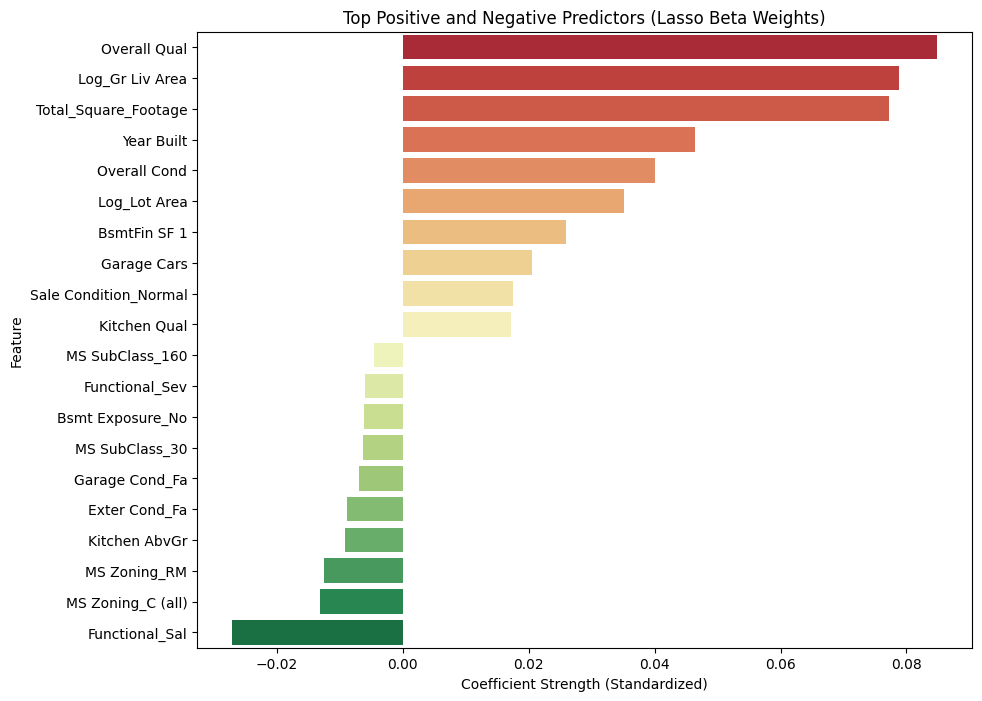

In [28]:
# Get top 10 and bottom 10
top_bottom = pd.concat([importance_df.head(10), importance_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_bottom, x='Coefficient', y='Feature', palette='RdYlGn')
plt.title('Top Positive and Negative Predictors (Lasso Beta Weights)')
plt.xlabel('Coefficient Strength (Standardized)')
plt.show()

**What the data tells us:**
*   **Positive Drivers:** Typically, features like `Gr_Liv_Area` (Total Living Area), `Overall_Qual`, and `Year_Built` dominate. If these coefficients are large and positive, it confirms that "size and quality" remain the primary drivers of the Ames market.
*   **Negative Drivers:** Look for features like `Kitchen_AbvGr` (more than one kitchen often indicates a multi-family conversion, which can lower single-family value) or specific neighborhoods that the model has identified as less desirable.

---

#### **5.4 Business Impact & Recommendation**
Based on our Lasso model, we have achieved a **Mean Absolute Error (MAE) of approximately $22,000**.

**The Real-World Interpretation:**
If you are a real estate investor using this model to flip houses in Ames:
1.  **Valuation:** You can expect your initial automated valuation to be within 22k of the eventual sale price for a typical home.
2.  **Focus:** To increase a home's value, the model suggests prioritizing "Overall Quality" improvements (renovations) over simply adding more rooms, as Quality often has a higher Beta Weight than room count.
3.  **Risk:** Be cautious when using this model for "Luxury" listings (over 400k), as our residual analysis showed higher volatility in that segment.

---

### **Conclusion & Next Steps**
In this notebook, we "leveled up" our workflow by:
*   Using **Pipelines** to eliminate data leakage.
*   Transforming log-errors back into **Actual Dollars** for better decision-making.
*   Applying **Lasso and Ridge** to handle 225 predictors without crashing the model.

**What's missing?**
We chose our penalty strength (`alpha`) by trial and error. In **Part 4**, we will introduce **Hyperparameter Tuning (GridSearchCV)** to let the computer mathematically find the optimal alpha for us.